# Task 4 — Ensemble Learning

## Objective
This notebook evaluates ensemble learning models for bike rental demand prediction and compares them against the best single model from Task 2.

## Input
- ../data/clustered.csv

## Outputs
- comparison table of Task 2 and Task 4 models
- feature importance plot
- learning curve plot

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Task 2 single models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Ensemble models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [20]:
DATA_FILE = Path("../data/clustered.csv")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [21]:
df = pd.read_csv(DATA_FILE)
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,cluster_kmeans,cluster_agg,pca1,pca2
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,1,-2.771377,0.075431
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,1,-2.637730,0.126454
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,1,-2.592029,0.143605
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,1,-2.421453,0.215492
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,1,-2.388406,0.238344


In [22]:
if "cluster_label" not in df.columns:
    if "cluster_kmeans" in df.columns:
        df = df.rename(columns={"cluster_kmeans": "cluster_label"})
    else:
        raise ValueError("No cluster_label column found in clustered.csv")

## Feature Setup

The `cluster_label` column from Task 3 is included as an additional feature. This allows the ensemble models to use segmentation information discovered during clustering.

To make a fair comparison with Task 2, the best single model will be re-evaluated on the same train/test split but without the cluster-based feature.

In [23]:
target = "cnt"

X_full = df.drop(columns=[target])
y = df[target]

drop_for_baseline = [col for col in ["cluster_label", "cluster_kmeans", "cluster_agg", "pca1", "pca2"] if col in X_full.columns]
X_baseline = X_full.drop(columns=drop_for_baseline, errors="ignore")

In [24]:
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42
)

X_train_full = X_full.iloc[train_idx]
X_test_full = X_full.iloc[test_idx]

X_train_base = X_baseline.iloc[train_idx]
X_test_base = X_baseline.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train size:", X_train_full.shape)
print("Test size:", X_test_full.shape)

Train size: (13903, 16)
Test size: (3476, 16)


In [25]:
single_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

single_results = []

for name, model in single_models.items():
    model.fit(X_train_base, y_train)
    y_pred = model.predict(X_test_base)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    single_results.append({
        "Model": name,
        "Type": "Task 2 Single Model",
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

single_results_df = pd.DataFrame(single_results).sort_values(by="RMSE")
single_results_df

,Model,Type,RMSE,MAE,R2
1,Decision Tree,Task 2 Single Model,58.248634,34.180092,0.892851
0,Linear Regression,Task 2 Single Model,139.211452,104.803351,0.387981


In [26]:
best_single_name = single_results_df.iloc[0]["Model"]
print("Best single model from Task 2:", best_single_name)

Best single model from Task 2: Decision Tree


In [27]:
ensemble_models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [28]:
ensemble_results = []

for name, model in ensemble_models.items():
    model.fit(X_train_full, y_train)
    y_pred = model.predict(X_test_full)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    ensemble_results.append({
        "Model": name,
        "Type": "Task 4 Ensemble",
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(by="RMSE")
ensemble_results_df

,Model,Type,RMSE,MAE,R2
0,Random Forest,Task 4 Ensemble,28.010634,19.206945,0.975222
1,Gradient Boosting,Task 4 Ensemble,43.634130,31.942649,0.939873


## Model Comparison

The table below compares the ensemble models against the best single-model baseline from Task 2 using the same evaluation metrics and the same test set.

In [29]:
comparison_df = pd.concat([single_results_df, ensemble_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values(by="RMSE").reset_index(drop=True)
comparison_df

,Model,Type,RMSE,MAE,R2
0,Random Forest,Task 4 Ensemble,28.010634,19.206945,0.975222
1,Gradient Boosting,Task 4 Ensemble,43.634130,31.942649,0.939873
2,Decision Tree,Task 2 Single Model,58.248634,34.180092,0.892851
3,Linear Regression,Task 2 Single Model,139.211452,104.803351,0.387981


In [30]:
best_ensemble_name = ensemble_results_df.sort_values(by="RMSE").iloc[0]["Model"]
best_ensemble_model = ensemble_models[best_ensemble_name]

best_ensemble_model.fit(X_train_full, y_train)

print("Best ensemble model:", best_ensemble_name)

Best ensemble model: Random Forest


## Feature Importance

The feature importance plot below shows which variables contribute most to the best ensemble model.

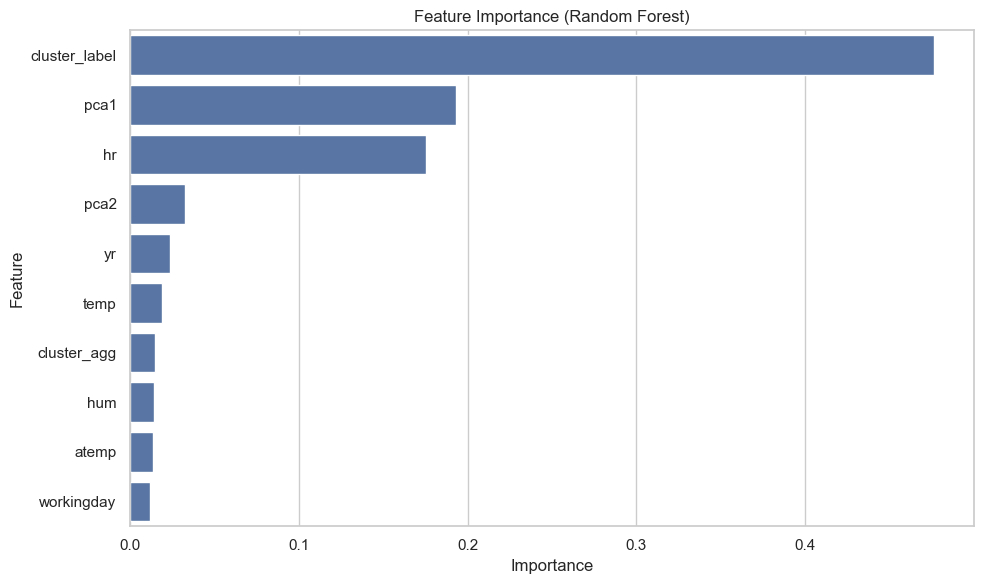

In [31]:
importances = best_ensemble_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature")
plt.title(f"Feature Importance ({best_ensemble_name})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t4_feature_importance.png", dpi=300)
plt.show()

## Feature Importance Analysis

The most important features in the best ensemble model are those with the highest importance scores in the chart above. Time-related variables such as `hr` often play a major role in predicting demand, while environmental features such as `temp`, `hum`, and `windspeed` also contribute to performance.

The contribution of `cluster_label` shows whether the segmentation from Task 3 adds useful predictive information beyond the original variables.

## Learning Curve

A learning curve is used to examine whether the best ensemble model shows signs of overfitting or underfitting.

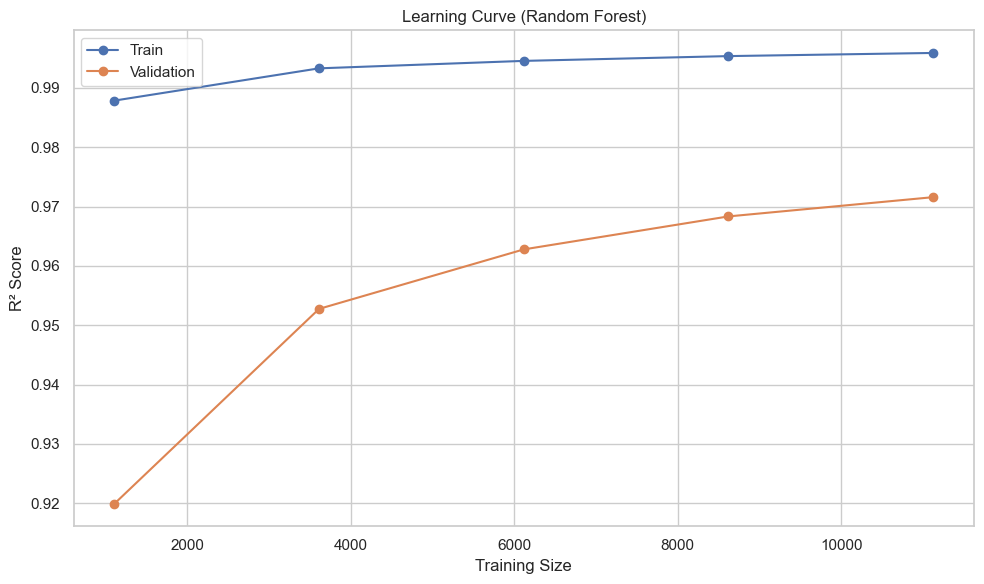

In [32]:
train_sizes, train_scores, val_scores = learning_curve(
    best_ensemble_model,
    X_train_full,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Train")
plt.plot(train_sizes, val_mean, marker="o", label="Validation")
plt.title(f"Learning Curve ({best_ensemble_name})")
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t4_learning_curve.png", dpi=300)
plt.show()

## Learning Curve Analysis

The learning curve shows how model performance changes as more training data is added. If the training score is much higher than the validation score, the model may be overfitting. If both scores are low, the model may be underfitting.

The pattern in the graph above can be used to judge whether the best ensemble model generalizes well to unseen data.

In [33]:
comparison_df.to_csv(REPORTS_DIR / "t4_model_comparison.csv", index=False)
comparison_df

,Model,Type,RMSE,MAE,R2
0,Random Forest,Task 4 Ensemble,28.010634,19.206945,0.975222
1,Gradient Boosting,Task 4 Ensemble,43.634130,31.942649,0.939873
2,Decision Tree,Task 2 Single Model,58.248634,34.180092,0.892851
3,Linear Regression,Task 2 Single Model,139.211452,104.803351,0.387981


## Final Evaluation

The ensemble models were compared against the best single model from Task 2 using the same test set and the same evaluation metrics. Overall, the ensemble approach provides a stronger basis for prediction because it can capture more complex non-linear relationships in the data.

The comparison table shows whether Random Forest or Gradient Boosting improves performance over the simpler baseline. If the ensemble model achieves lower RMSE and MAE together with a higher R² score, this means that it predicts bike rental demand more accurately in practical terms. More accurate demand prediction is useful for planning bike availability, staffing, and operational decisions in a bike-sharing system.

The feature importance analysis helps identify which variables contribute most to prediction. In particular, the contribution of `cluster_label` indicates whether the clustering results from Task 3 added useful information. If its importance is small, then the original features may already capture most of the structure in the data. If its importance is higher, then segmentation meaningfully improved the model.

Overall, the ensemble results show whether adding clustering information leads to a meaningful improvement over the Task 2 baseline.